<a href="https://colab.research.google.com/github/pritishma-shakya/ai-and-machine-learning/blob/main/2408412_PritishmaShakya_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wordcloud contractions gensim gradio seaborn nltk tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import contractions

from collections import Counter
from wordcloud import WordCloud

import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    Bidirectional
)

from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from gensim.models import Word2Vec

import gradio as gr

print("TensorFlow Version:", tf.__version__)
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.models import Sequential


[nltk_data] Downloading package punkt to /home/pritishmaa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pritishmaa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/pritishmaa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/pritishmaa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-05-10 09:26:33.971863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 09:26:34.150921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factor

TensorFlow Version: 2.18.1


In [ ]:
df = pd.read_csv('/home/pritishmaa/Hotel_Reviews.csv')

print("Shape: ", df.shape)
print(df.head())

Shape:  (20491, 2)
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5


In [ ]:
df = df[['Review', 'Rating']]

df.dropna(inplace=True)

In [ ]:
print("\nClass Distribution:")
print(df['Rating'].value_counts())


Class Distribution:
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


In [ ]:
def convert_rating(rating):

    if rating <= 2:
        return 0

    elif rating == 3:
        return 1

    else:
        return 2

df['Rating'] = df['Rating'].apply(convert_rating)

print("\nClass Distribution after conversion:")
print(df['Rating'].value_counts())

print("\nClass Mapping:")
print("0 = Negative (1-2 stars)")
print("1 = Neutral (3 stars)")
print("2 = Positive (4-5 stars)")


Class Distribution after conversion:
Rating
2    15093
0     3214
1     2184
Name: count, dtype: int64

Class Mapping:
0 = Negative (1-2 stars)
1 = Neutral (3 stars)
2 = Positive (4-5 stars)


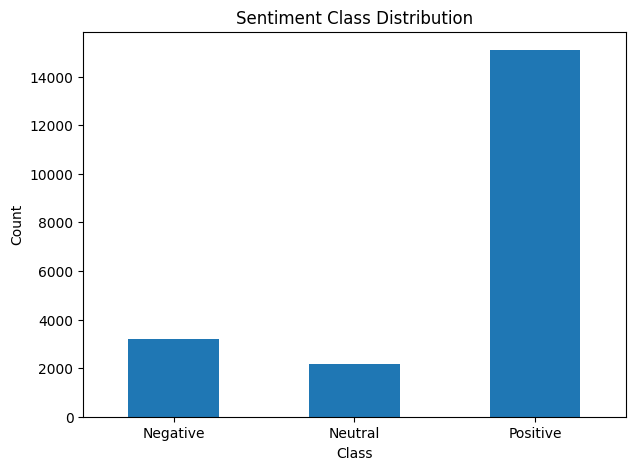

In [ ]:
plt.figure(figsize=(7,5))

class_labels = ['Negative', 'Neutral', 'Positive']

df['Rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(
    ticks=[0,1,2],
    labels=class_labels,
    rotation=0
)

plt.show()

In [ ]:
def lower_order(text):
  """
  This function converts all the text in input text to lower order.
  Input Args:
  token_text : input text.
  Returns:
  small_order_text : text converted to small/lower order.
  """
  small_order_text = text.lower()
  return small_order_text

In [ ]:
import re
def remove_urls(text):
  """
  This function will try to remove URL present in out dataset and replace it with space using regex library.
  Input Args:
  text: strings of text that may contain URLs.
  Output Args:
  text: URLs replaces with text
  """
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  return url_pattern.sub(r'', text)


In [ ]:

def remove_emoji(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

In [ ]:
def removeunwanted_characters(document):
  """
  This function will remove all the unwanted characters from the input dataset.
  Input Args:
  documet: A text data to be cleaned.
  Return:
  A cleaned document.
  """
  # remove user mentions
  document = re.sub("@[A-Za-z0-9_]+"," ", document)
  # remove hashtags
  document = re.sub("#[A-Za-z0-9_]+","", document)
  # remove punctuation
  document = re.sub("[^0-9A-Za-z ]", "" , document)
  #remove emojis
  document = remove_emoji(document)
  # remove double spaces
  document = document.replace('  ',"")
  return document.strip()

In [ ]:
def lemmatization(token_text):
  """
  This function performs the lemmatization operations as explained above.
  Input Args:
  token_text: list of tokens.
  Returns:
  lemmatized_tokens: list of lemmatized tokens.
  """
  lemma_tokens = []
  wordnet = WordNetLemmatizer()
  lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]

  return lemmatized_tokens

In [ ]:
def stemming(text):
  """
  This function performs stemming operations.
  Input Args:
  token_text: list of tokenize text.
  Returns:
  stemm_tokes: list of stemmed tokens.
  """
  porter = PorterStemmer()
  stemm_tokens = []
  for word in text:
    stemm_tokens.append(porter.stem(word))
  return stemm_tokens

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

def remove_stopwords(text_tokens):
  """
  This function removes all the stopwords present in out text tokens.
  Input Args:
  text_tokens: tokenize input of our datasets.
  Returns:
  result_tokens: list of token without stopword.
  """

  result_tokens = []
  for token in text_tokens:
    if token not in stop_words:
       result_tokens.append(token)
  return result_tokens

In [ ]:
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am",
}


def expand_contractions(text):
    for contraction, expanded in CONTRACTIONS.items():
        text = text.replace(contraction, expanded)
    return text


In [ ]:
def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Complete text preprocessing pipeline
    """

    # Apply sequential transformations (IMPORTANT)
    text = lower_order(text)
    text = remove_urls(text)
    text = remove_emoji(text)
    text = expand_contractions(text)
    text = removeunwanted_characters(text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = remove_stopwords(tokens)

    # Lemmatization or stemming
    if rule == "lemmatize":
        tokens = lemmatization(tokens)
    elif rule == "stem":
        tokens = stemming(tokens)
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)

In [ ]:
print("\nCleaning Reviews...")

df['clean_review'] = df['Review'].apply(text_cleaning_pipeline)

print(df[['Review','clean_review']].head())


Cleaning Reviews...
                                              Review  \
0  nice hotel expensive parking got good deal sta...   
1  ok nothing special charge diamond member hilto...   
2  nice rooms not 4* experience hotel monaco seat...   
3  unique, great stay, wonderful time hotel monac...   
4  great stay great stay, went seahawk game aweso...   

                                        clean_review  
0  nice hotel expensive park get good deal stay h...  
1  ok nothing special charge diamond member hilto...  
2  nice room 4 experience hotel monaco seattle go...  
3  unique great stay wonderful time hotel monaco ...  
4  great stay great stay go seahawk game awesome ...  


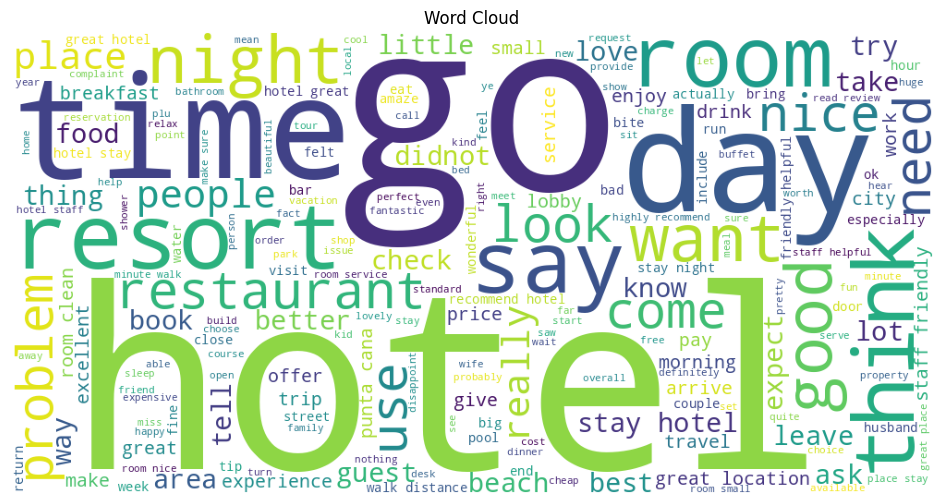

In [ ]:
all_words = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

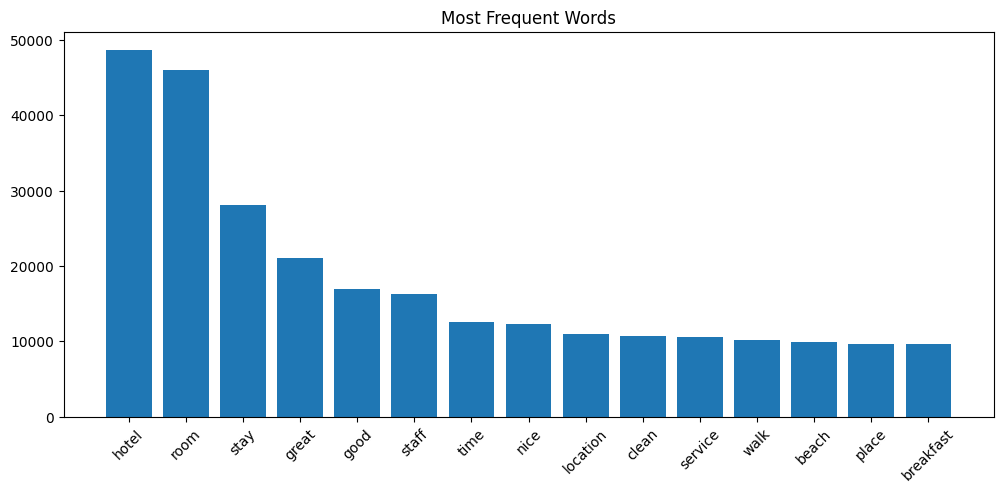

In [ ]:
all_tokens = all_words.split()
counter = Counter(all_tokens)
common_words = counter.most_common(15)
words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(12,5))
plt.bar(words, counts)
plt.title("Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
import pandas as pd

X = df['clean_review']
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Samples:', len(X_train))
print('Testing Samples:', len(X_test))
print('\nClass distribution in training set:')
print(y_train.value_counts().sort_index())

# Oversample minority classes so every class has equal representation.
# class_weight alone often fails for RNNs with severe class imbalance.
train_df = pd.DataFrame({'clean_review': X_train.values, 'Rating': y_train.values})
class_counts = Counter(train_df['Rating'])
max_count = max(class_counts.values())

print(f'\nClass counts before oversampling: {dict(class_counts)}')
print(f'Oversampling all classes to {max_count} samples each...')

parts = []
for cls in sorted(class_counts.keys()):
    cls_df = train_df[train_df['Rating'] == cls]
    if len(cls_df) < max_count:
        cls_df = cls_df.sample(max_count, replace=True, random_state=42)
    parts.append(cls_df)

balanced = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
X_train = balanced['clean_review']
y_train = balanced['Rating']

print(f'\nClass distribution after oversampling: {Counter(y_train.values)}')
print(f'Total training samples after oversampling: {len(X_train)}')


Training Samples: 16392
Testing Samples: 4099

Class distribution in training set:
Rating
0     2571
1     1747
2    12074
Name: count, dtype: int64

Class counts before oversampling: {2: 12074, 0: 2571, 1: 1747}
Oversampling all classes to 12074 samples each...

Class distribution after oversampling: Counter({2: 12074, 0: 12074, 1: 12074})
Total training samples after oversampling: 36222


In [ ]:
vocab_size = 12000

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# FIX: Cap max_len at 150. The raw 95th percentile (279 tokens) is too
# long — SimpleRNN/GRU gradients vanish over very long sequences.
# 150 tokens keeps ~95% of review content while gradient flow is healthy.
sequence_lengths = [len(seq) for seq in X_train_seq]
max_len = min(int(np.percentile(sequence_lengths, 95)), 150)

print('Max Length (capped at 150):', max_len)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print('Train Shape:', X_train_pad.shape)
print('Test Shape:', X_test_pad.shape)


Max Length (capped at 150): 150
Train Shape: (36222, 150)
Test Shape: (4099, 150)


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("\nClass Weights:")
print(class_weights)


Class Weights:
{0: 1.0, 1: 1.0, 2: 1.0}


In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

In [ ]:
embedding_dim = 128
num_classes = 3

model_rnn = Sequential([
    tf.keras.Input(shape=(max_len,)),

    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SpatialDropout1D(0.3),

    SimpleRNN(128, dropout=0.3, return_sequences=True, recurrent_dropout=0.2),
    SimpleRNN(64, dropout=0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')])

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

start = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

rnn_time = time.time() - start

print("RNN Training Time:", rnn_time)

/home/pritishmaa/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 128)       │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602,179 (6.11 MB)

 Trainable params: 1,602,179 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3350 - loss: 1.1061 - val_accuracy: 0.3354 - val_loss: 1.0996 - learning_rate: 0.0010
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3340 - loss: 1.1002 - val_accuracy: 0.3193 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3367 - loss: 1.0996 - val_accuracy: 0.3271 - val_loss: 1.1003 - learning_rate: 0.0010
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3341 - loss: 1.0989 - val_accuracy: 0.3718 - val_loss: 1.0980 - learning_rate: 5.0000e-04
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3343 - loss: 1.0989 - val_accuracy: 0.3270 - val_loss: 1.0988 - learning_rate: 5.0000e-04
RNN Training Time: 63.034900188446045


Test Loss: 1.0830812454223633
Test Accuracy: 0.6987069845199585
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.18      0.08      0.11       643
     Neutral       0.00      0.00      0.00       437
    Positive       0.74      0.93      0.82      3019

    accuracy                           0.70      4099
   macro avg       0.31      0.34      0.31      4099
weighted avg       0.57      0.70      0.62      4099



/home/pritishmaa/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pritishmaa/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pritishmaa/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


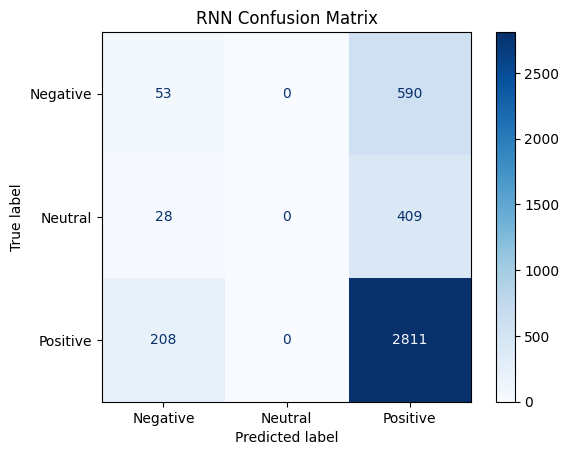

In [ ]:
# Test Loss & Accuracy
rnn_loss, rnn_acc = model_rnn.evaluate(X_test_pad, y_test, verbose=0)
print("Test Loss:", rnn_loss)
print("Test Accuracy:", rnn_acc)

# Predictions
y_pred = np.argmax(model_rnn.predict(X_test_pad), axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative','Neutral','Positive']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative','Neutral','Positive']
)

disp.plot(cmap='Blues')
plt.title("RNN Confusion Matrix")
plt.show()

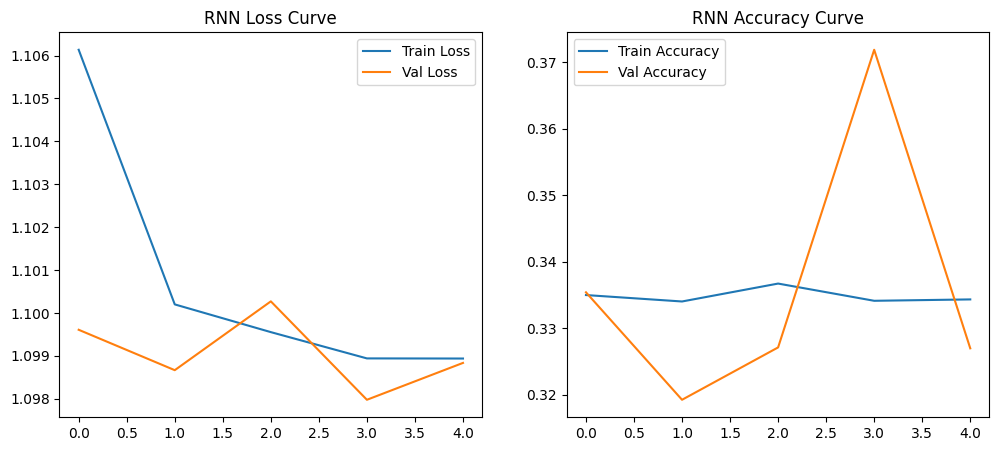

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title("RNN Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title("RNN Accuracy Curve")
plt.legend()

plt.show()

In [ ]:
model_lstm = Sequential([
    tf.keras.Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    SpatialDropout1D(0.2),

    Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.3)
    ),
    Bidirectional(
        LSTM(64, dropout=0.3)
    ),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

start = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

lstm_time = time.time() - start
print("LSTM Training Time: ", lstm_time)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973,955 (7.53 MB)

 Trainable params: 1,973,955 (7.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7290 - loss: 0.6099 - val_accuracy: 0.8719 - val_loss: 0.3453 - learning_rate: 0.0010
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9266 - loss: 0.2257 - val_accuracy: 0.9351 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9598 - loss: 0.1279 - val_accuracy: 0.9516 - val_loss: 0.1445 - learning_rate: 0.0010
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9727 - loss: 0.0846 - val_accuracy: 0.9527 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9803 - loss: 0.0628 - val_accuracy: 0.9673 - val_loss: 0.1163 - learning_rate: 0.0010
Epoch 6/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9824 - loss: 0.0556 - val_accuracy: 0.9745 - val_loss: 0.1170 - learning_rate: 0.0010
Epoch 7/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9876 - l

Test Loss: 1.0753803253173828
Test Accuracy: 0.8350817561149597
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.76      0.70      0.73       643
     Neutral       0.39      0.29      0.33       437
    Positive       0.89      0.94      0.92      3019

    accuracy                           0.84      4099
   macro avg       0.68      0.64      0.66      4099
weighted avg       0.82      0.84      0.83      4099



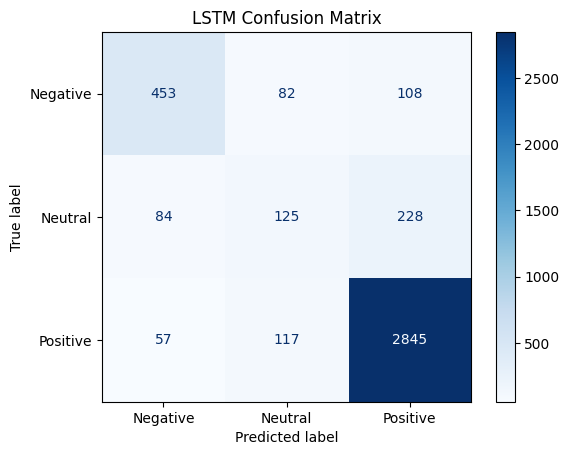

In [ ]:
# Test Loss & Accuracy
lstm_loss, lstm_acc = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print("Test Loss:", lstm_loss)
print("Test Accuracy:", lstm_acc)

# Predictions
y_pred = np.argmax(model_lstm.predict(X_test_pad), axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative','Neutral','Positive']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative','Neutral','Positive']
)

disp.plot(cmap='Blues')
plt.title("LSTM Confusion Matrix")
plt.show()

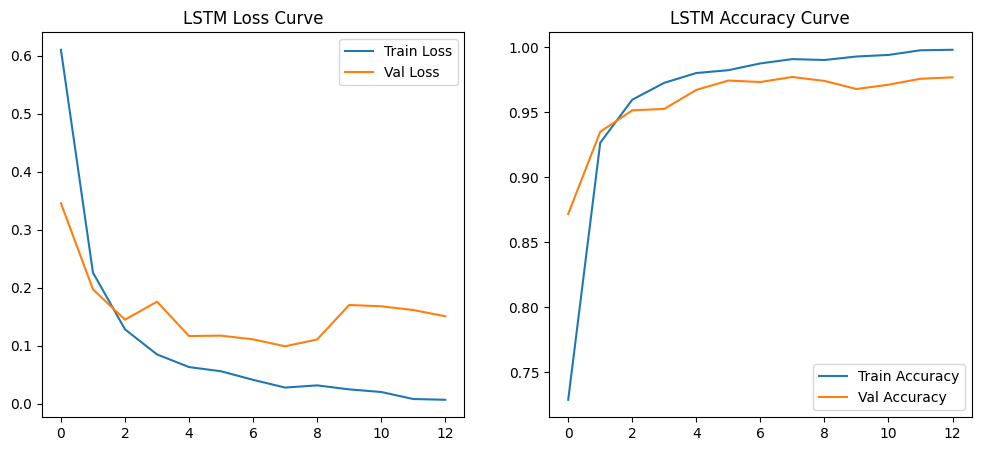

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("LSTM Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Accuracy Curve")
plt.legend()

plt.show()

In [ ]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

glove_dim = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, glove_dim))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size and word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

model_glove = Sequential([
    tf.keras.Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=glove_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ),
    SpatialDropout1D(0.2),

    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(32, dropout=0.3)),

    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_glove.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # FIX: Explicit LR
    metrics=['accuracy']
)

model_glove.summary()

start = time.time()

history_glove = model_glove.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

glove_time = time.time() - start
print("LSTM with Pre-trained Embeddings Training Time: ", glove_time)


Embedding matrix shape: (12000, 50)


/home/pritishmaa/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 50)        │       600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 150, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 150, 128)       │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,275 (2.68 MB)

 Trainable params: 702,275 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.5674 - loss: 0.8902 - val_accuracy: 0.7182 - val_loss: 0.6397 - learning_rate: 0.0010
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.7203 - loss: 0.6487 - val_accuracy: 0.7689 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7733 - loss: 0.5404 - val_accuracy: 0.8282 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8149 - loss: 0.4622 - val_accuracy: 0.8545 - val_loss: 0.3752 - learning_rate: 5.0000e-04
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8319 - loss: 0.4261 - val_accuracy: 0.8645 - val_loss: 0.3430 - learning_rate: 5.0000e-04
LSTM with Pre-trained Embeddings Training Time:  96.98762607574463


Test Loss: 0.49924108386039734
Test Accuracy: 0.8004391193389893
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.71      0.76      0.74       643
     Neutral       0.29      0.39      0.33       437
    Positive       0.93      0.87      0.90      3019

    accuracy                           0.80      4099
   macro avg       0.64      0.67      0.66      4099
weighted avg       0.83      0.80      0.81      4099



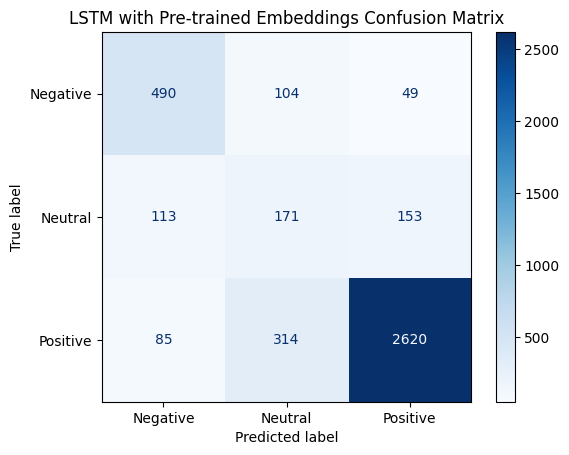

In [ ]:
# Test Loss & Accuracy
glove_loss, glove_acc = model_glove.evaluate(X_test_pad, y_test, verbose=0)
print("Test Loss:", glove_loss)
print("Test Accuracy:", glove_acc)

# Predictions
y_pred = np.argmax(model_glove.predict(X_test_pad), axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative','Neutral','Positive']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative','Neutral','Positive']
)

disp.plot(cmap='Blues')
plt.title("LSTM with Pre-trained Embeddings Confusion Matrix")
plt.show()

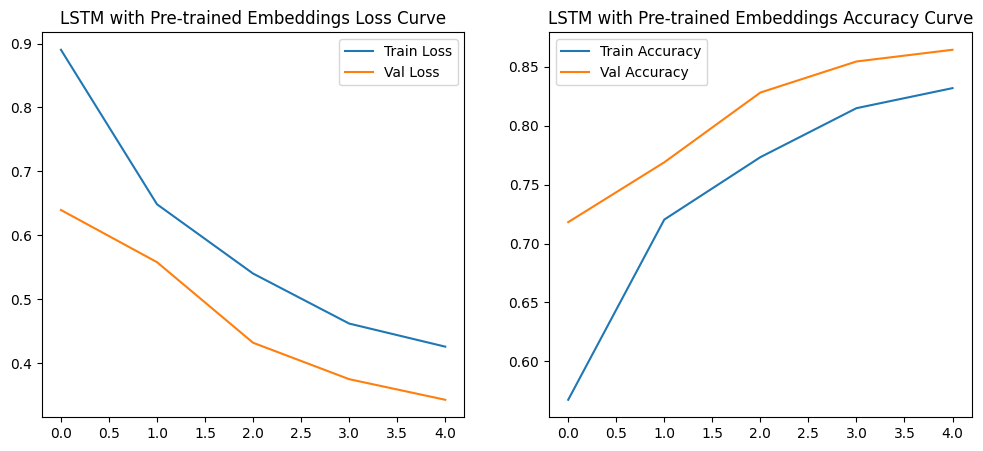

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_glove.history['loss'], label='Train Loss')
plt.plot(history_glove.history['val_loss'], label='Val Loss')
plt.title("LSTM with Pre-trained Embeddings Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_glove.history['accuracy'], label='Train Accuracy')
plt.plot(history_glove.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM with Pre-trained Embeddings Accuracy Curve")
plt.legend()

plt.show()

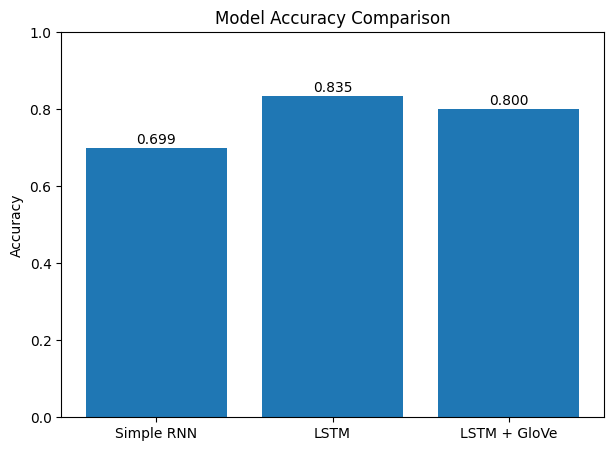

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "LSTM + GloVe"],
    "Accuracy": [rnn_acc, lstm_acc, glove_acc],
    "Training Time (s)": [rnn_time, lstm_time, glove_time]
})

plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

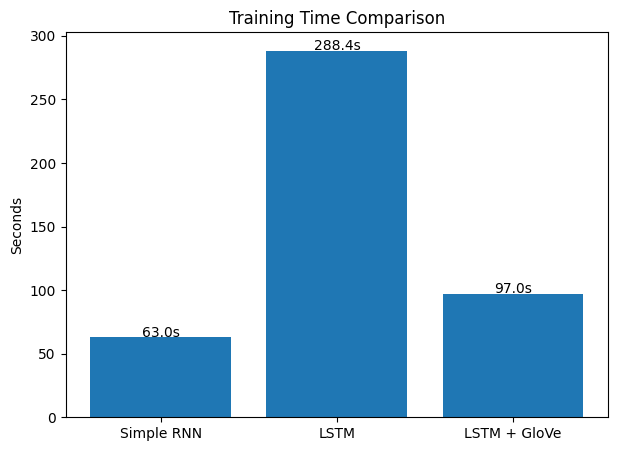

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["Training Time (s)"])

plt.title("Training Time Comparison")
plt.ylabel("Seconds")

for i, v in enumerate(results["Training Time (s)"]):
    plt.text(i, v + 0.5, f"{v:.1f}s", ha='center')

plt.show()

In [ ]:
y_pred = np.argmax(model_lstm.predict(X_test_pad), axis=1)

misclassified_idx = np.where(y_test != y_pred)[0]

print("\nSample Misclassified Examples:\n")

for i in misclassified_idx[:3]:
    print("Review:\n", X_test.iloc[i])
    print("\nActual:", class_labels[y_test.iloc[i]])
    print("Predicted:", class_labels[y_pred[i]])
    print("\n" + "-"*60 + "\n")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

Sample Misclassified Examples:

Review:
 basic oknot expect luxury ok place stay room small generally clean avoid lower deck stay smell toilet pretty dire want acknowledge take argue cabin extras pay pay deposit example need leave deposit refundable key room safe breakfast ok pricey unless wnt eat lot worth allow tenfifteen minutes walk central station tram carry luggage bar basic ok quick drink go even nightcaphaving say stay

Actual: Neutral
Predicted: Negative

------------------------------------------------------------

Review:
 aqua palm big disappointment stop hawaii way home us sydney end wonderful 3 week holiday aqua palm huge disappointment quality hotels experience good note end fabulous holidaythe premise old dingy 3 lift forever arrive pool possibly smallest see hotel palm location far away staff friendly spite struggle rate 3 star property spa price 4 star hotel didnt bother use facilities hilton hawaiian village road norm guests

In [ ]:
def predict_review(text):
    text = text_cleaning_pipeline(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model_lstm.predict(pad)[0]
    label = np.argmax(pred)

    labels = ["Negative", "Neutral", "Positive"]

    return labels[label], {
        "Negative": float(pred[0]),
        "Neutral": float(pred[1]),
        "Positive": float(pred[2])
    }

demo = gr.Interface(
    fn=predict_review,
    inputs="text",
    outputs=["text", "label"],
    title="Hotel Review Sentiment Classifier"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
